In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/age_insurance.csv')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
file_path = '/content/drive/MyDrive/Colab/age_insurance.csv'

df = pd.read_csv(file_path)

print(df.head())
print("\nDataset Shape:", df.shape)

   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset Shape: (300, 3)


In [17]:
print("Column Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Column Names:
Index(['Age', 'Insurance', 'InsurancePlan'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            300 non-null    int64
 1   Insurance      300 non-null    int64
 2   InsurancePlan  300 non-null    int64
dtypes: int64(3)
memory usage: 7.2 KB
None


In [18]:
X = df[["Age"]]
y = df["Insurance"]

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   Age
0   56
1   69
2   46
3   32
4   60

Target:
0    0
1    1
2    1
3    0
4    1
Name: Insurance, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 1)
Testing data: (60, 1)


In [20]:
binary_model = LogisticRegression()

binary_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
y_pred = binary_model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 0 0 1 1 1 0 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 1 1 1]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7833333333333333


In [23]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Insurance", "Has Insurance"]
    )
)

Classification Report:
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60



In [24]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[17  8]
 [ 5 30]]


In [25]:
new_age = pd.DataFrame({
    "Age": [22, 45, 63]
})

predictions = binary_model.predict(new_age)

probabilities = binary_model.predict_proba(new_age)[:, 1]

for age_val, pred, prob in zip(
    new_age["Age"],
    predictions,
    probabilities
):
    status = "Yes" if pred == 1 else "No"

    print(
        f"Age {age_val}: "
        f"Insurance = {status}, "
        f"Probability of Yes = {prob:.2f}"
    )

Age 22: Insurance = No, Probability of Yes = 0.07
Age 45: Insurance = Yes, Probability of Yes = 0.68
Age 63: Insurance = Yes, Probability of Yes = 0.97


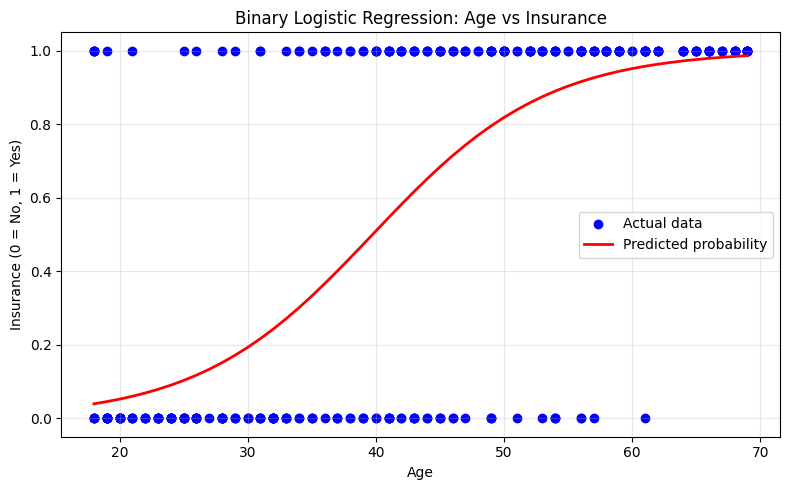

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Insurance"],
    color="blue",
    label="Actual data"
)

age_range = pd.DataFrame({
    "Age": range(
        int(df["Age"].min()),
        int(df["Age"].max()) + 1
    )
})

predicted_probability = binary_model.predict_proba(
    age_range
)[:, 1]

plt.plot(
    age_range["Age"],
    predicted_probability,
    color="red",
    linewidth=2,
    label="Predicted probability"
)

plt.xlabel("Age")
plt.ylabel("Insurance (0 = No, 1 = Yes)")
plt.title("Binary Logistic Regression: Age vs Insurance")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [27]:
plt.savefig(
    "/content/binary_logistic_plot.png",
    dpi=300,
    bbox_inches="tight"
)

print("Plot saved successfully!")
print("Location: /content/binary_logistic_plot.png")

Plot saved successfully!
Location: /content/binary_logistic_plot.png


<Figure size 640x480 with 0 Axes>